# ==================================================
# Trabalho Prático – Análise de Dados: Fast Food nos EUA (2019)
# Disciplina: Lógica de Programação | Curso: Administração
# Fonte: QSR Magazine – QSR50 (2020)
# ===============================================

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
from google.colab import files

print("Faça o upload do arquivo top_50_fast_food_US-1.csv")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.columns = df.columns.str.strip().str.lstrip('\ufeff')  # remove BOM se houver

print(f"\n✅ Dados carregados! Shape: {df.shape}")
display(df.head())

Faça o upload do arquivo top_50_fast_food_US-1.csv


Saving top_50_fast_food_US-1.csv to top_50_fast_food_US-1 (1).csv

✅ Dados carregados! Shape: (50, 8)


,company,category,sales_in_millions_2019,sales_per_unit_thousands_2019,franchised_units_2019,company_owned_units_2019,total_units_2019,unit_change_from_2018
0,mcdonalds,burger,40413,2912,13154,692,13846,-66
1,starbucks,snack,21550,1454,6768,8273,15041,216
2,chick_fil_a,chicken,11000,4517,2500,0,2500,130
3,taco_bell,global,11000,1502,6622,467,7089,181
4,burger_king,burger,10300,1399,7294,52,7346,16


In [ ]:
print("=== Informações do Dataset ===")
print(df.info())
print("\n=== Valores ausentes ===")
print(df.isnull().sum())
print("\n=== Estatísticas descritivas ===")
display(df.describe())

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   company                        50 non-null     object
 1   category                       50 non-null     object
 2   sales_in_millions_2019         50 non-null     int64 
 3   sales_per_unit_thousands_2019  50 non-null     int64 
 4   franchised_units_2019          50 non-null     int64 
 5   company_owned_units_2019       50 non-null     int64 
 6   total_units_2019               50 non-null     int64 
 7   unit_change_from_2018          50 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 3.3+ KB
None

=== Valores ausentes ===
company                          0
category                         0
sales_in_millions_2019           0
sales_per_unit_thousands_2019    0
franchised_units_2019            0
company_owned_units_2

,sales_in_millions_2019,sales_per_unit_thousands_2019,franchised_units_2019,company_owned_units_2019,total_units_2019,unit_change_from_2018
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,4292.16000,1537.780000,2765.240000,470.400000,3236.240000,10.020000
std,6598.80288,921.338363,4123.294787,1229.366055,4390.605154,163.001501
min,563.00000,247.000000,0.000000,0.000000,185.000000,-996.000000
25%,851.25000,852.500000,487.000000,32.750000,767.000000,-19.750000
50%,1785.00000,1286.000000,1200.000000,156.000000,1517.500000,8.000000
75%,4786.75000,1753.000000,3180.500000,363.000000,3484.250000,54.250000
max,40413.00000,4517.000000,23802.000000,8273.000000,23802.000000,253.000000


In [ ]:
# ============================================================
# ETAPA 1 – ANÁLISE DE CONTEXTO
# ============================================================

print(f"📌 Total de redes no dataset: {len(df)}")
print(f"\n📌 Categorias presentes:")
print(df['category'].value_counts().to_string())

print("\n📌 Período: 2019 | Fonte: QSR Magazine – QSR50 (2020)")

📌 Total de redes no dataset: 50

📌 Categorias presentes:
category
burger      14
chicken      9
sandwich     9
snack        6
global       6
pizza        6

📌 Período: 2019 | Fonte: QSR Magazine – QSR50 (2020)


In [ ]:
ranks = ['1º lugar', '2º lugar', '3º lugar', '4º lugar', '5º lugar']

print("\n📌 Top 5 redes em vendas totais (US$ milhões):")
sales_top5 = df.nlargest(5, 'sales_in_millions_2019').copy()
sales_top5['Rank'] = ranks[:len(sales_top5)]
display(sales_top5[['Rank', 'company', 'sales_in_millions_2019']].reset_index(drop=True))

print("\n📌 Top 5 redes em número total de unidades:")
units_top5 = df.nlargest(5, 'total_units_2019').copy()
units_top5['Rank'] = ranks[:len(units_top5)]
display(units_top5[['Rank', 'company', 'total_units_2019']].reset_index(drop=True))


📌 Top 5 redes em vendas totais (US$ milhões):


,Rank,company,sales_in_millions_2019
0,1º lugar,mcdonalds,40413
1,2º lugar,starbucks,21550
2,3º lugar,chick_fil_a,11000
3,4º lugar,taco_bell,11000
4,5º lugar,burger_king,10300



📌 Top 5 redes em número total de unidades:


,Rank,company,total_units_2019
0,1º lugar,subway,23802
1,2º lugar,starbucks,15041
2,3º lugar,mcdonalds,13846
3,4º lugar,dunkin,9630
4,5º lugar,pizza_hut,7416


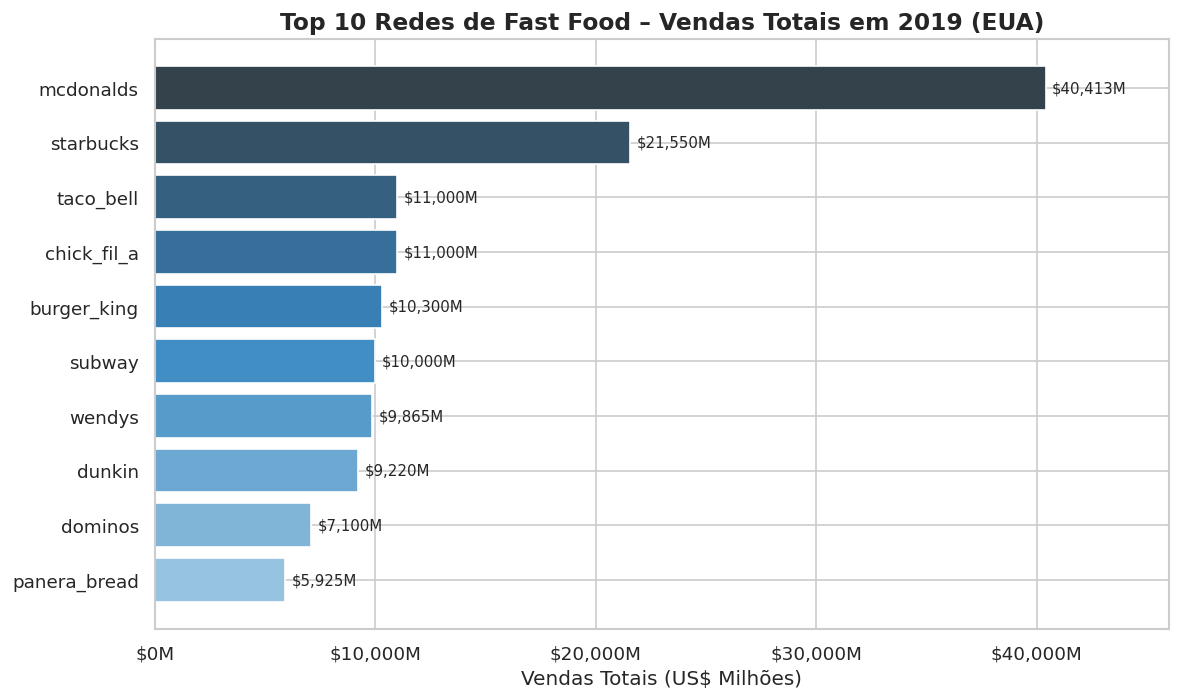


📝 Análise: McDonald's lidera com US$ 40,4 bilhões — quase o dobro do 2º colocado
(Starbucks, US$ 21,5 bi). Chick-fil-A e Taco Bell empatam em 3º com US$ 11 bi cada.
O mercado é altamente concentrado: as 5 primeiras redes respondem por ~54 bilhões
de um total de ~214 bilhões no ranking.



In [ ]:
top10 = df.nlargest(10, 'sales_in_millions_2019').sort_values('sales_in_millions_2019')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['company'], top10['sales_in_millions_2019'],
               color=sns.color_palette("Blues_d", len(top10)))

ax.set_xlabel("Vendas Totais (US$ Milhões)", fontsize=12)
ax.set_title("Top 10 Redes de Fast Food – Vendas Totais em 2019 (EUA)", fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 300, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}M', va='center', fontsize=9)

ax.set_xlim(0, 46000)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig("grafico_top10_vendas.png")
plt.show()

print("""
📝 Análise: McDonald's lidera com US$ 40,4 bilhões — quase o dobro do 2º colocado
(Starbucks, US$ 21,5 bi). Chick-fil-A e Taco Bell empatam em 3º com US$ 11 bi cada.
O mercado é altamente concentrado: as 5 primeiras redes respondem por ~54 bilhões
de um total de ~214 bilhões no ranking.
""")

In [ ]:
# ============================================================
# ETAPA 2 – ANÁLISE DE EFICIÊNCIA
# ============================================================

ranks = ['1º lugar', '2º lugar', '3º lugar', '4º lugar', '5º lugar']

print("📌 Top 5 redes mais eficientes (maior venda por unidade - US$ mil):")
most_efficient_top5 = df.nlargest(5, 'sales_per_unit_thousands_2019').copy()
most_efficient_top5['Rank'] = ranks[:len(most_efficient_top5)]
display(most_efficient_top5[['Rank', 'company','sales_per_unit_thousands_2019','total_units_2019']].reset_index(drop=True))

print("\n📌 Top 5 redes menos eficientes (menor venda por unidade - US$ mil):")
least_efficient_top5 = df.nsmallest(5, 'sales_per_unit_thousands_2019').copy()
least_efficient_top5['Rank'] = ranks[:len(least_efficient_top5)]
display(least_efficient_top5[['Rank', 'company','sales_per_unit_thousands_2019','total_units_2019']].reset_index(drop=True))

📌 Top 5 redes mais eficientes (maior venda por unidade - US$ mil):


,Rank,company,sales_per_unit_thousands_2019,total_units_2019
0,1º lugar,chick_fil_a,4517,2500
1,2º lugar,shake_shack,4214,185
2,3º lugar,raising_canes,3208,457
3,4º lugar,whataburger,3080,830
4,5º lugar,mcdonalds,2912,13846



📌 Top 5 redes menos eficientes (menor venda por unidade - US$ mil):


,Rank,company,sales_per_unit_thousands_2019,total_units_2019
0,1º lugar,baskin_robbins,247,2524
1,2º lugar,subway,410,23802
2,3º lugar,papa_murphys,551,1368
3,4º lugar,auntie_annes,562,1211
4,5º lugar,churchs_chicken,688,1050


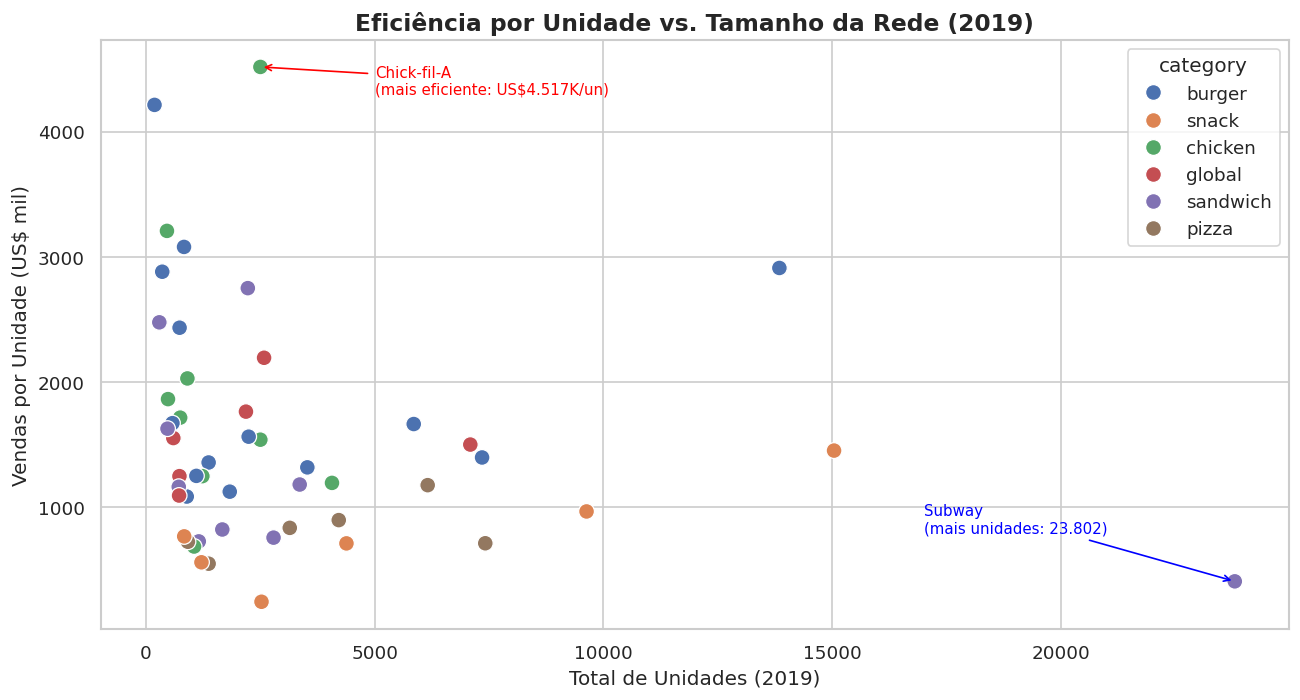


📝 Análise: Não há relação direta entre tamanho e eficiência.
Chick-fil-A, com apenas 2.500 unidades, lidera em vendas por loja (US$4.517K),
enquanto Subway, com 23.802 unidades (a maior rede), tem apenas US$410K por unidade
— 11x menos. Isso evidencia que foco, posicionamento e modelo operacional
superam estratégias de expansão pura.



In [ ]:
mais_eficiente = df.loc[df['sales_per_unit_thousands_2019'].idxmax()]  # chick_fil_a: 4517, 2500 un
maior_rede     = df.loc[df['total_units_2019'].idxmax()]               # subway: 23802 un, 410 venda/un

fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(data=df, x='total_units_2019', y='sales_per_unit_thousands_2019',
                hue='category', s=90, ax=ax)

# Destaque Chick-fil-A (mais eficiente)
ax.annotate("Chick-fil-A\n(mais eficiente: US$4.517K/un)",
            xy=(mais_eficiente['total_units_2019'], mais_eficiente['sales_per_unit_thousands_2019']),
            xytext=(5000, 4300),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

# Destaque Subway (mais unidades)
ax.annotate("Subway\n(mais unidades: 23.802)",
            xy=(maior_rede['total_units_2019'], maior_rede['sales_per_unit_thousands_2019']),
            xytext=(17000, 800),
            fontsize=9, color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'))

ax.set_xlabel("Total de Unidades (2019)", fontsize=12)
ax.set_ylabel("Vendas por Unidade (US$ mil)", fontsize=12)
ax.set_title("Eficiência por Unidade vs. Tamanho da Rede (2019)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("grafico_dispersao_eficiencia.png")
plt.show()

print("""
📝 Análise: Não há relação direta entre tamanho e eficiência.
Chick-fil-A, com apenas 2.500 unidades, lidera em vendas por loja (US$4.517K),
enquanto Subway, com 23.802 unidades (a maior rede), tem apenas US$410K por unidade
— 11x menos. Isso evidencia que foco, posicionamento e modelo operacional
superam estratégias de expansão pura.
""")

In [ ]:
# ============================================================
# ETAPA 3 – FRANQUIAS vs UNIDADES PRÓPRIAS
# ============================================================

df['pct_franqueadas'] = (df['franchised_units_2019'] / df['total_units_2019']) * 100
df['pct_proprias']    = (df['company_owned_units_2019'] / df['total_units_2019']) * 100

print("📌 Redes 100% franqueadas:")
display(df[df['pct_franqueadas'] == 100][['company','total_units_2019','unit_change_from_2018']])

print("\n📌 Redes 100% próprias:")
display(df[df['pct_proprias'] == 100][['company','total_units_2019','unit_change_from_2018']])

corr = df['pct_franqueadas'].corr(df['unit_change_from_2018'])
print(f"\n📌 Correlação entre % franqueadas e variação de unidades: {corr:.3f}")
print("→ Correlação fraca e negativa: alto percentual de franquias NÃO garante crescimento.")

📌 Redes 100% franqueadas:


,company,total_units_2019,unit_change_from_2018
2,chick_fil_a,2500,130
5,subway,23802,-996
7,dunkin,9630,42
39,tim_hortons,715,-12
47,baskin_robbins,2524,-26



📌 Redes 100% próprias:


,company,total_units_2019,unit_change_from_2018
10,chipotle,2580,130
32,in_n_out_burger,354,14



📌 Correlação entre % franqueadas e variação de unidades: -0.157
→ Correlação fraca e negativa: alto percentual de franquias NÃO garante crescimento.


/tmp/ipykernel_2796/1677378778.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['modelo'] != 'Misto'],


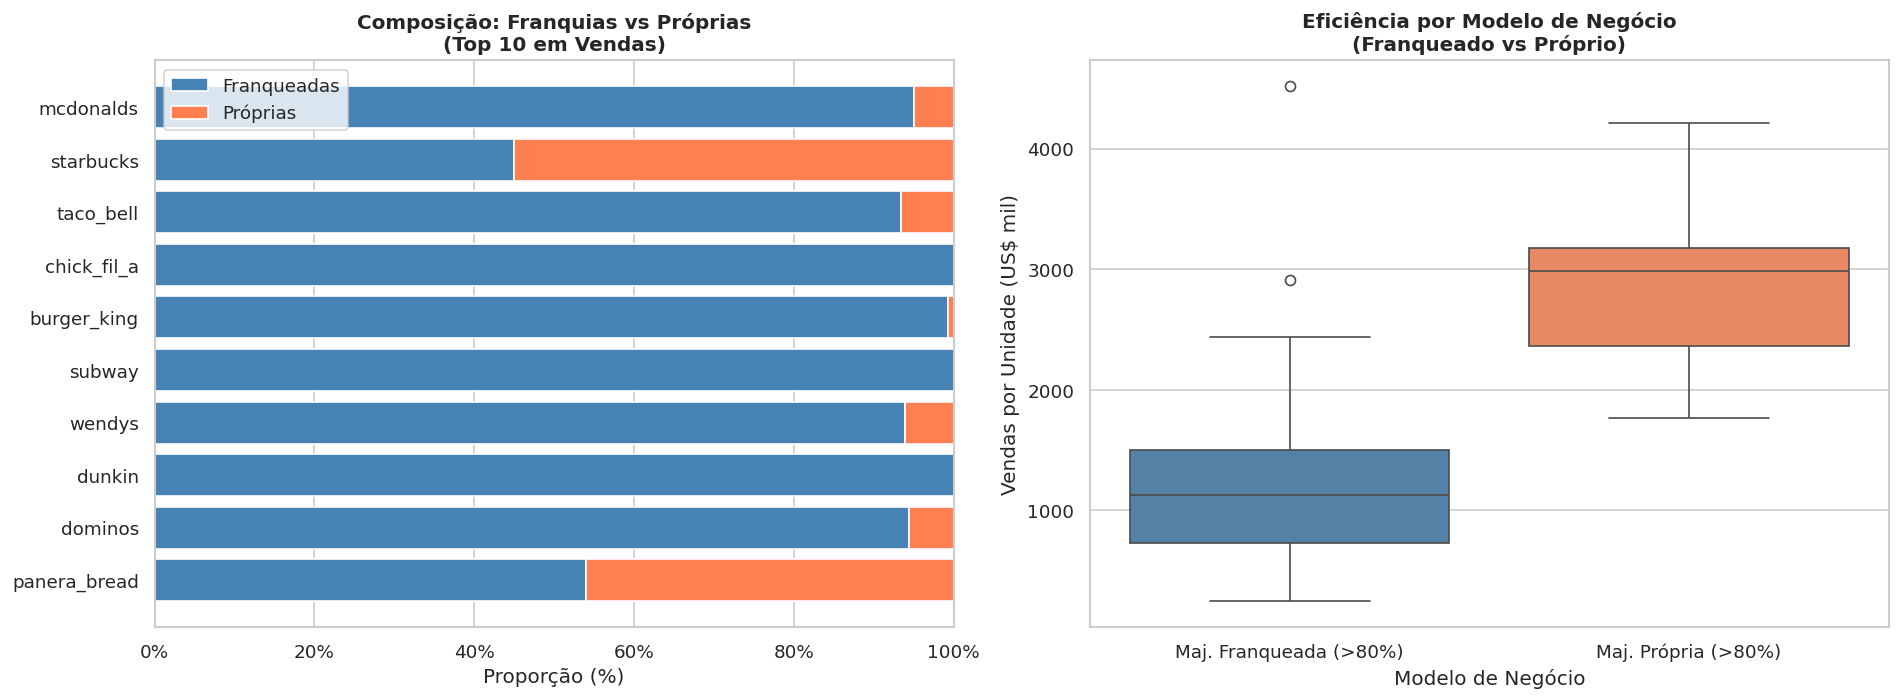


📌 Média de vendas por unidade por modelo:
modelo
Maj. Franqueada (>80%)    1247.696970
Maj. Própria (>80%)       2890.666667

📝 Análise: Redes majoritariamente próprias (>80%) têm média de US$2.891K/unidade,
enquanto as majoritariamente franqueadas têm média de US$1.248K/unidade — uma diferença
de 2,3x. Chipotle e In-N-Out Burger (100% próprias) são exemplos de alta eficiência
com controle total da operação. Isso sugere que o modelo próprio favorece
qualidade e desempenho por loja, enquanto o franqueado favorece escala.



In [ ]:
top10_v = df.nlargest(10, 'sales_in_millions_2019').sort_values('sales_in_millions_2019')

df['modelo'] = np.where(df['pct_franqueadas'] > 80, 'Maj. Franqueada (>80%)',
               np.where(df['pct_proprias'] > 80,    'Maj. Própria (>80%)', 'Misto'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras empilhadas
axes[0].barh(top10_v['company'], top10_v['pct_franqueadas'], label='Franqueadas', color='steelblue')
axes[0].barh(top10_v['company'], top10_v['pct_proprias'],
             left=top10_v['pct_franqueadas'], label='Próprias', color='coral')
axes[0].set_xlabel("Proporção (%)")
axes[0].set_title("Composição: Franquias vs Próprias\n(Top 10 em Vendas)", fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

# Boxplot
sns.boxplot(data=df[df['modelo'] != 'Misto'],
            x='modelo', y='sales_per_unit_thousands_2019',
            palette=['steelblue','coral'], ax=axes[1])
axes[1].set_xlabel("Modelo de Negócio")
axes[1].set_ylabel("Vendas por Unidade (US$ mil)")
axes[1].set_title("Eficiência por Modelo de Negócio\n(Franqueado vs Próprio)", fontweight='bold')

plt.tight_layout()
plt.savefig("grafico_franquia_vs_propria.png")
plt.show()

grupo = df[df['modelo'] != 'Misto'].groupby('modelo')['sales_per_unit_thousands_2019'].mean()
print("\n📌 Média de vendas por unidade por modelo:")
print(grupo.to_string())

print("""
📝 Análise: Redes majoritariamente próprias (>80%) têm média de US$2.891K/unidade,
enquanto as majoritariamente franqueadas têm média de US$1.248K/unidade — uma diferença
de 2,3x. Chipotle e In-N-Out Burger (100% próprias) são exemplos de alta eficiência
com controle total da operação. Isso sugere que o modelo próprio favorece
qualidade e desempenho por loja, enquanto o franqueado favorece escala.
""")

/tmp/ipykernel_2796/1677378778.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['modelo'] != 'Misto'],


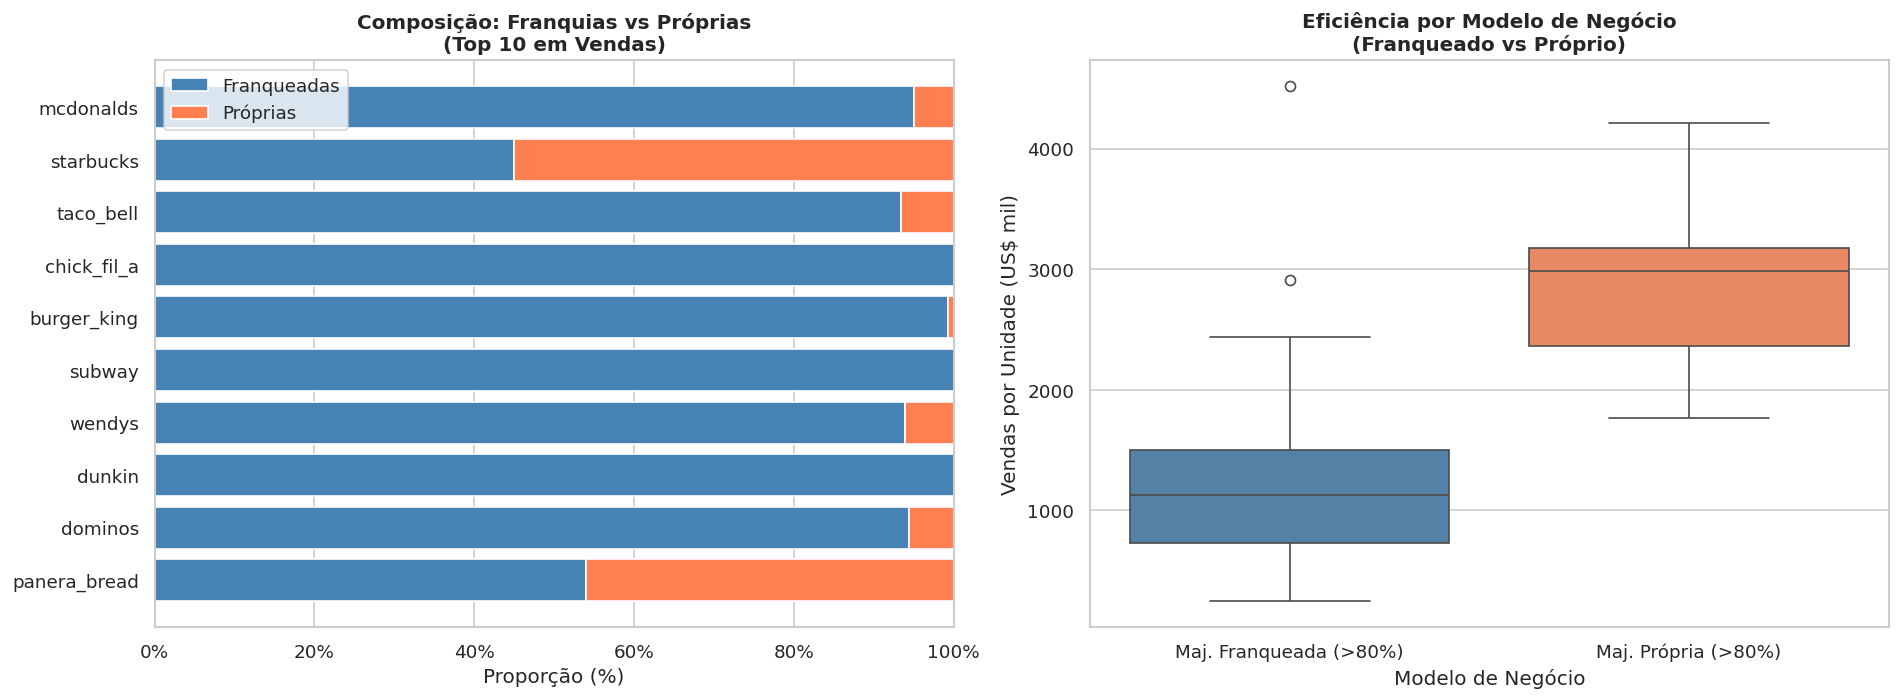


📌 Média de vendas por unidade por modelo:
modelo
Maj. Franqueada (>80%)    1247.696970
Maj. Própria (>80%)       2890.666667

📝 Análise: Redes majoritariamente próprias (>80%) têm média de US$2.891K/unidade,
enquanto as majoritariamente franqueadas têm média de US$1.248K/unidade — uma diferença
de 2,3x. Chipotle e In-N-Out Burger (100% próprias) são exemplos de alta eficiência
com controle total da operação. Isso sugere que o modelo próprio favorece
qualidade e desempenho por loja, enquanto o franqueado favorece escala.



In [ ]:
top10_v = df.nlargest(10, 'sales_in_millions_2019').sort_values('sales_in_millions_2019')

df['modelo'] = np.where(df['pct_franqueadas'] > 80, 'Maj. Franqueada (>80%)',
               np.where(df['pct_proprias'] > 80,    'Maj. Própria (>80%)', 'Misto'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras empilhadas
axes[0].barh(top10_v['company'], top10_v['pct_franqueadas'], label='Franqueadas', color='steelblue')
axes[0].barh(top10_v['company'], top10_v['pct_proprias'],
             left=top10_v['pct_franqueadas'], label='Próprias', color='coral')
axes[0].set_xlabel("Proporção (%)")
axes[0].set_title("Composição: Franquias vs Próprias\n(Top 10 em Vendas)", fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

# Boxplot
sns.boxplot(data=df[df['modelo'] != 'Misto'],
            x='modelo', y='sales_per_unit_thousands_2019',
            palette=['steelblue','coral'], ax=axes[1])
axes[1].set_xlabel("Modelo de Negócio")
axes[1].set_ylabel("Vendas por Unidade (US$ mil)")
axes[1].set_title("Eficiência por Modelo de Negócio\n(Franqueado vs Próprio)", fontweight='bold')

plt.tight_layout()
plt.savefig("grafico_franquia_vs_propria.png")
plt.show()

grupo = df[df['modelo'] != 'Misto'].groupby('modelo')['sales_per_unit_thousands_2019'].mean()
print("\n📌 Média de vendas por unidade por modelo:")
print(grupo.to_string())

print("""
📝 Análise: Redes majoritariamente próprias (>80%) têm média de US$2.891K/unidade,
enquanto as majoritariamente franqueadas têm média de US$1.248K/unidade — uma diferença
de 2,3x. Chipotle e In-N-Out Burger (100% próprias) são exemplos de alta eficiência
com controle total da operação. Isso sugere que o modelo próprio favorece
qualidade e desempenho por loja, enquanto o franqueado favorece escala.
""")

In [ ]:
# ============================================================
# ETAPA 4 – SEGMENTAÇÃO POR CATEGORIA
# ============================================================

cat = df.groupby('category').agg(
    vendas_totais       = ('sales_in_millions_2019',       'sum'),
    media_venda_unidade = ('sales_per_unit_thousands_2019','mean'),
    total_unidades      = ('total_units_2019',             'sum'),
    variacao_media      = ('unit_change_from_2018',        'mean')
).reset_index().sort_values('vendas_totais', ascending=False)

display(cat.style.format({
    'vendas_totais': '{:,.2f}',
    'media_venda_unidade': '{:,.2f}',
    'total_unidades': '{:,.2f}',
    'variacao_media': '{:,.2f}'
}))

print(f"\n📌 Maior faturamento total:       burger  → US$81.612M")
print(f"📌 Maior eficiência média/unidade: chicken → US$2.001K/unidade")
print(f"📌 Maior crescimento de unidades:  global  → +64,8 unidades médias")

,category,vendas_totais,media_venda_unidade,total_unidades,variacao_media
0,burger,"81,612.00","1,997.86","40,680.00",-0.43
5,snack,"36,296.00",785.50,"33,621.00",50.33
1,chicken,"27,160.00","2,001.33","13,932.00",42.33
4,sandwich,"26,374.00","1,325.33","36,467.00",-70.56
2,global,"22,805.00","1,560.17","13,901.00",64.83
3,pizza,"20,361.00",817.50,"23,211.00",11.67



📌 Maior faturamento total:       burger  → US$81.612M
📌 Maior eficiência média/unidade: chicken → US$2.001K/unidade
📌 Maior crescimento de unidades:  global  → +64,8 unidades médias


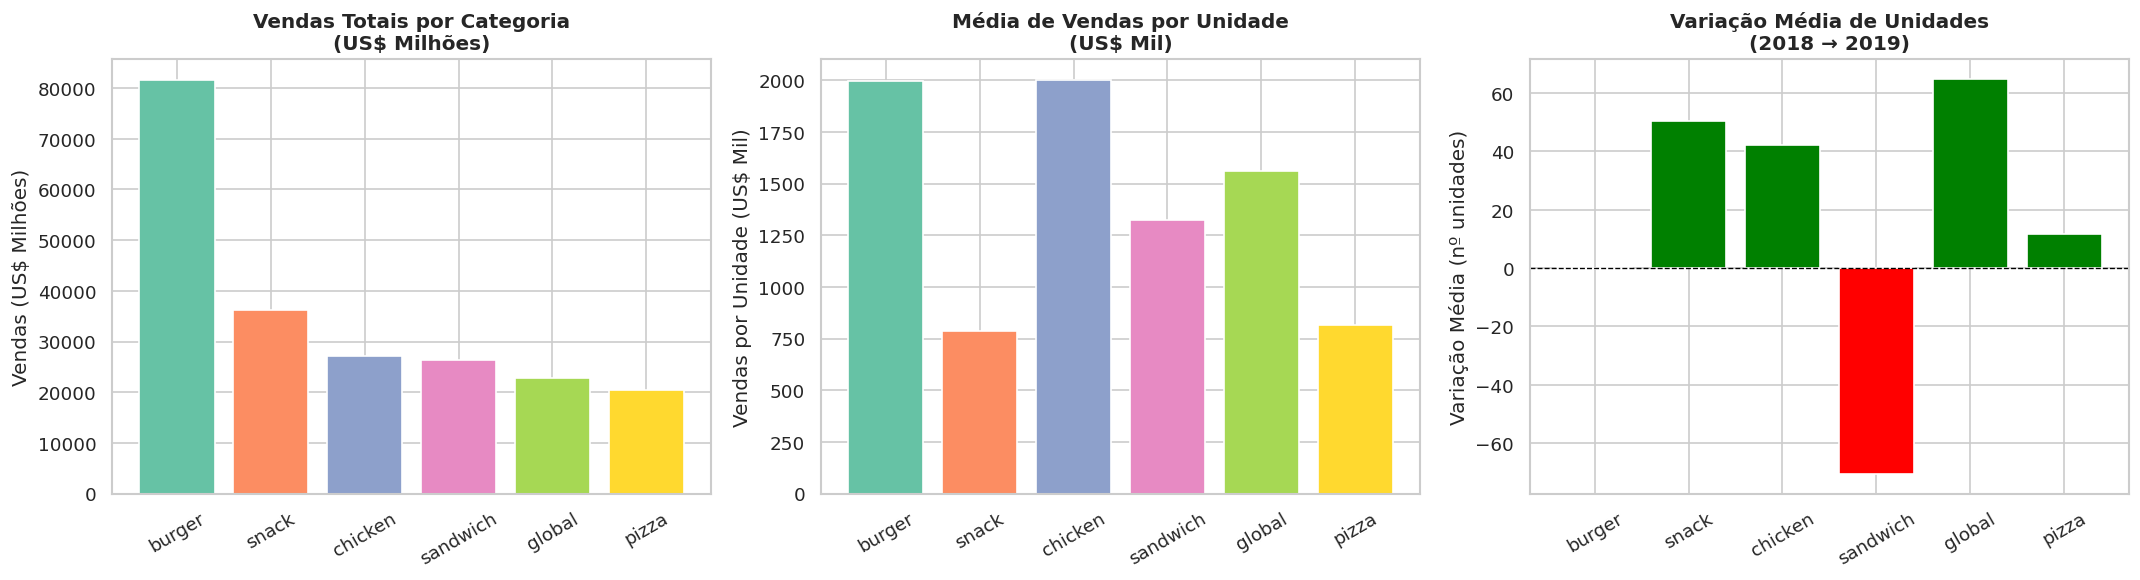


📝 Análise:
- Burger domina em faturamento total (US$81,6 bi), puxado por McDonald's e Burger King.
- Chicken lidera em eficiência média por unidade (US$2.001K), impulsionado por
  Chick-fil-A, Raising Cane's e Whataburger.
- Global teve o maior crescimento médio de unidades (+64,8), refletindo expansão
  de redes como Taco Bell, Chipotle e Panda Express.
- Sandwich foi a categoria com maior retração (-70,6 un/rede em média), puxada
  principalmente pela queda de 996 unidades do Subway.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("Set2", len(cat))
ordem = cat['category'].tolist()

# Vendas totais
axes[0].bar(cat['category'], cat['vendas_totais'], color=palette)
axes[0].set_title("Vendas Totais por Categoria\n(US$ Milhões)", fontweight='bold')
axes[0].set_ylabel("Vendas (US$ Milhões)")
axes[0].tick_params(axis='x', rotation=30)

# Média por unidade
axes[1].bar(cat['category'], cat['media_venda_unidade'], color=palette)
axes[1].set_title("Média de Vendas por Unidade\n(US$ Mil)", fontweight='bold')
axes[1].set_ylabel("Vendas por Unidade (US$ Mil)")
axes[1].tick_params(axis='x', rotation=30)

# Variação de unidades
cores_var = ['green' if v >= 0 else 'red' for v in cat['variacao_media']]
axes[2].bar(cat['category'], cat['variacao_media'], color=cores_var)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title("Variação Média de Unidades\n(2018 → 2019)", fontweight='bold')
axes[2].set_ylabel("Variação Média (nº unidades)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("grafico_categorias.png")
plt.show()

print("""
📝 Análise:
- Burger domina em faturamento total (US$81,6 bi), puxado por McDonald's e Burger King.
- Chicken lidera em eficiência média por unidade (US$2.001K), impulsionado por
  Chick-fil-A, Raising Cane's e Whataburger.
- Global teve o maior crescimento médio de unidades (+64,8), refletindo expansão
  de redes como Taco Bell, Chipotle e Panda Express.
- Sandwich foi a categoria com maior retração (-70,6 un/rede em média), puxada
  principalmente pela queda de 996 unidades do Subway.
""")

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              CONCLUSÕES FINAIS DA ANÁLISE                   ║
╚══════════════════════════════════════════════════════════════╝

1. CONCENTRAÇÃO DE MERCADO
   McDonald's lidera com US$40,4 bi em vendas — 1,9x maior que o 2º colocado
   (Starbucks, US$21,5 bi). As 5 maiores redes concentram ~54% do faturamento
   total do ranking QSR50.

2. EFICIÊNCIA ≠ ESCALA
   Chick-fil-A (2.500 un) tem a maior venda por unidade: US$4.517K.
   Subway, a maior rede em unidades (23.802), tem apenas US$410K/un.
   Redes menores e focadas superam gigantes em produtividade por loja.

3. MODELO PRÓPRIO = MAIOR EFICIÊNCIA POR LOJA
   Redes majoritariamente próprias faturam em média US$2.891K/un — 2,3x mais
   que as majoritariamente franqueadas (US$1.248K/un). O controle da operação
   parece favorecer o desempenho individual de cada unidade.

4. BURGER DOMINA EM VOLUME; CHICKEN LIDERA EM EFICIÊNCIA
   A categoria burger fatura US$81,6 bi (38% do total), mas chicken tem a maior
   média de vendas por unidade (US$2.001K), mostrando alto valor por loja.

5. CRESCIMENTO SELETIVO
   A categoria global (+64,8 un/rede) liderou a expansão em 2019.
   Sandwich (-70,6 un/rede) foi a que mais retraiu, fortemente influenciada
   pela perda de 996 unidades do Subway — sinal de reposicionamento do setor.
""")


╔══════════════════════════════════════════════════════════════╗
║              CONCLUSÕES FINAIS DA ANÁLISE                   ║
╚══════════════════════════════════════════════════════════════╝

1. CONCENTRAÇÃO DE MERCADO
   McDonald's lidera com US$40,4 bi em vendas — 1,9x maior que o 2º colocado
   (Starbucks, US$21,5 bi). As 5 maiores redes concentram ~54% do faturamento
   total do ranking QSR50.

2. EFICIÊNCIA ≠ ESCALA
   Chick-fil-A (2.500 un) tem a maior venda por unidade: US$4.517K.
   Subway, a maior rede em unidades (23.802), tem apenas US$410K/un.
   Redes menores e focadas superam gigantes em produtividade por loja.

3. MODELO PRÓPRIO = MAIOR EFICIÊNCIA POR LOJA
   Redes majoritariamente próprias faturam em média US$2.891K/un — 2,3x mais
   que as majoritariamente franqueadas (US$1.248K/un). O controle da operação
   parece favorecer o desempenho individual de cada unidade.

4. BURGER DOMINA EM VOLUME; CHICKEN LIDERA EM EFICIÊNCIA
   A categoria burger fatura US$81,6 bi (3